# Load cells info


In [1]:
import numpy as np
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
from bluepysnap import Circuit
from bluepysnap.bbp import Cell

CircuitPath = 'O1_data_physiology/' # edges files not inclued in https://github.com/FernandoSBorges/
circuit_path = CircuitPath + 'circuit_config.json'
circuit = Circuit(circuit_path)
cells = circuit.nodes["S1nonbarrel_neurons"]
nodesinfo = cells.get()

# nodesinfo[nodesinfo['layer'] == '4'].head()
%matplotlib inline

In [2]:
def distance3D(gidpre,gidpost):
    return np.sqrt(np.power(nodesinfo['x'][gidpre]-nodesinfo['x'][gidpost],2)+np.power(nodesinfo['y'][gidpre]-nodesinfo['y'][gidpost],2)+np.power(nodesinfo['z'][gidpre]-nodesinfo['z'][gidpost],2))

def distance2D(gidpre,gidpost):
    return np.sqrt(np.power(nodesinfo['x'][gidpre]-nodesinfo['x'][gidpost],2)+np.power(nodesinfo['y'][gidpre]-nodesinfo['y'][gidpost],2))

def distance2Dmean(gidpre, mean_x, mean_y):
    return np.sqrt(np.power(nodesinfo['x_new'][gidpre]-mean_x,2)+np.power(nodesinfo['y_new'][gidpre]-mean_y,2))

print(cells.property_values(Cell.REGION))

mtypes = sorted(cells.property_values(Cell.MTYPE))

i = 0
mntypes = {}
for mn in sorted(mtypes):
    mntypes[mn] = i
    i+=1

{'S1FL', 'S1J', 'S1DZ'}


In [3]:
f = open('node_sets.json')
node_sets = json.load(f)

mean_x, mean_y = np.mean(nodesinfo['x_new']), np.mean(nodesinfo['y_new'])
node_gid = []
nodepremtype_new = []
mtype_new = []


node_gid = []
hoclist = []
Morpholist = []
node_threshold_current = []
node_holding_current = []


hex = 'hex0'
# for gid in node_sets['hex0']['node_id']:
# for gid in [117619, 142340, 142768, 142891, 141786,138337, 142077, 138315, 141829, 142671, 142352, 138475, 141536, 142859, 142058, 142814]:
# for gid in [141766, 138220, 108767, 108729, 108749, 138433, 141757, 141803, 138337]:
for gid in node_sets['hex0']['node_id']:
    # if 'L4_' in nodesinfo['mtype'][gid] and distance2Dmean(gid, mean_x, mean_y) > 0.0 and distance2Dmean(gid, mean_x, mean_y) < 50.0 and 'INH' in nodesinfo['synapse_class'][gid]:
    if 'L4_' in nodesinfo['mtype'][gid] and distance2Dmean(gid, mean_x, mean_y) > 0.0 and distance2Dmean(gid, mean_x, mean_y) < 50.0 and 'INH' in nodesinfo['synapse_class'][gid]:
        nodepremtype_new.append(mntypes[nodesinfo['mtype'][gid]])
        if nodesinfo['mtype'][gid] not in mtype_new:
            mtype_new.append(nodesinfo['mtype'][gid])

        iV70 = (-73.0 - nodesinfo['@dynamics:resting_potential'][gid])/nodesinfo['@dynamics:input_resistance'][gid]

        # print(len(node_gid),gid,nodesinfo['synapse_class'][gid],nodesinfo['mtype'][gid],nodesinfo['model_template'][gid],nodesinfo['morphology'][gid],hex,distance2Dmean(gid, mean_x, mean_y))
        print("%d \t%d %s %s %.1f %.2f %.1f %.2f" % (len(node_gid),gid,nodesinfo['synapse_class'][gid],nodesinfo['mtype'][gid], 
                                                     1000*(nodesinfo['@dynamics:threshold_current'][gid]+nodesinfo['@dynamics:holding_current'][gid]-iV70),nodesinfo['@dynamics:resting_potential'][gid],
                                                     1000*iV70,nodesinfo['@dynamics:input_resistance'][gid]))

        current1 = cells.get(gid,['@dynamics:threshold_current']).values[0]
        holding_current1 = cells.get(gid,['@dynamics:holding_current']).values[0]
        # print("%d %.5f %.5f" % (gid,current1,holding_current1))

        node_gid.append(gid)
        hoclist.append(nodesinfo['model_template'][gid][4:])
        Morpholist.append(nodesinfo['morphology'][gid])
        node_threshold_current.append(current1)
        node_holding_current.append(holding_current1)


for gid in [108767, 141766, 138433]:
        nodepremtype_new.append(mntypes[nodesinfo['mtype'][gid]])
        if nodesinfo['mtype'][gid] not in mtype_new:
            mtype_new.append(nodesinfo['mtype'][gid])

        iV70 = (-73.0 - nodesinfo['@dynamics:resting_potential'][gid])/nodesinfo['@dynamics:input_resistance'][gid]

        # print(len(node_gid),gid,nodesinfo['synapse_class'][gid],nodesinfo['mtype'][gid],nodesinfo['model_template'][gid],nodesinfo['morphology'][gid],hex,distance2Dmean(gid, mean_x, mean_y))
        print("%d \t%d %s %s %.1f %.2f %.1f %.2f" % (len(node_gid),gid,nodesinfo['synapse_class'][gid],nodesinfo['mtype'][gid], 
                                                     1000*(nodesinfo['@dynamics:threshold_current'][gid]+nodesinfo['@dynamics:holding_current'][gid]-iV70),nodesinfo['@dynamics:resting_potential'][gid],
                                                     1000*iV70,nodesinfo['@dynamics:input_resistance'][gid]))

        current1 = cells.get(gid,['@dynamics:threshold_current']).values[0]
        holding_current1 = cells.get(gid,['@dynamics:holding_current']).values[0]
        # print("%d %.5f %.5f" % (gid,current1,holding_current1))

        node_gid.append(gid)
        hoclist.append(nodesinfo['model_template'][gid][4:])
        Morpholist.append(nodesinfo['morphology'][gid])
        node_threshold_current.append(current1)
        node_holding_current.append(holding_current1)

# non central col
# for hex in node_sets['hex_O1']:
#     for gid in node_sets[hex]['node_id']:
#         if 'L4' in nodesinfo['mtype'][gid] and distance2Dmean(gid, mean_x, mean_y) > 500.0 and distance2Dmean(gid, mean_x, mean_y) < 502.0:
#             node_gid.append(gid)
#             nodepremtype_new.append(mntypes[nodesinfo['mtype'][gid]])
#             if nodesinfo['mtype'][gid] not in mtype_new:
#                 mtype_new.append(nodesinfo['mtype'][gid])

#             print(len(node_gid),gid,nodesinfo['mtype'][gid],hex,distance2Dmean(gid, mean_x, mean_y))

0 	117396 INH L4_NGC 9.3 -73.69 3.1 220.62
1 	117619 INH L4_SBC 14.6 -73.32 1.2 271.43
2 	138315 INH L4_NBC 36.5 -73.69 6.6 104.91
3 	138402 INH L4_NBC 2.2 -73.27 1.0 276.61
4 	138475 INH L4_NBC 41.3 -78.39 30.1 178.85
5 	141838 INH L4_MC 2.2 -69.37 -15.5 233.46
6 	142058 INH L4_MC 23.5 -71.88 -7.2 155.31
7 	142207 INH L4_MC 6.5 -71.32 -4.6 361.26
8 	142232 INH L4_MC 11.1 -69.46 -11.7 303.68
9 	142352 INH L4_LBC 21.6 -70.93 -7.6 270.26
10 	142695 INH L4_LBC 129.9 -78.91 160.9 36.72
11 	142804 INH L4_LBC 208.2 -79.41 180.9 35.44
12 	142872 INH L4_LBC 4.2 -73.50 1.0 522.24
13 	108767 INH L4_BP 16.8 -75.15 9.4 230.06
14 	141766 INH L4_BTC 19.0 -74.29 6.5 200.13
15 	138433 INH L4_NBC 35.7 -74.15 8.6 134.04


# Testing over all reconstruct cells

In [4]:
from netpyne import specs, sim

# Network parameters
netParams = specs.NetParams()  # object of class NetParams to store the network parameters

numprocs=1


In [5]:
cellName_list = {}
cellName_list2 = []
gid_list = {}

Epops = []
Ipops = []

cellName_list2 = []

#node_gid = [139867, 141213, 141369, 133426, 135956, 137858, 114264, 114284, 115007]

# node_gid = [108767, 141766, 138433, 139867, 141213, 141369, 133426, 135956, 137858, 114264, 114284, 115007]

# node_gid = [108767, 141766, 138433] # 142232, <- play with this FS - AP < 100 mV

for gid in node_gid:
# for gid in [108767, 141766, 138433, 139867, 141213, 141369, 133426, 135956, 137858, 114264, 114284, 115007]:
# for gid in [108767, 141766, 138433, 141213, 133426, 135956,  137858, 114264]:
# for gid in [114264]:

    cellName = nodesinfo['mtype'][gid] + '_' + nodesinfo['etype'][gid]

    cellName_list2.append(cellName)

    cellName_list[gid] = cellName + '_' + str(len(cellName_list2)-1)
    gid_list[cellName + '_' + str(len(cellName_list2)-1)] = gid

    print('%s %s %s 1 1 %d' % (cellName + '_' + str(len(cellName_list2)-1),nodesinfo['mtype'][gid],nodesinfo['etype'][gid],gid))

    if 'cADpyr' in cellName:
        Epops.append(cellName + '_' + str(len(cellName_list2)-1))
    else:
        Ipops.append(cellName + '_' + str(len(cellName_list2)-1))

L4_NGC_cNAC_0 L4_NGC cNAC 1 1 117396
L4_SBC_bNAC_1 L4_SBC bNAC 1 1 117619
L4_NBC_cNAC_2 L4_NBC cNAC 1 1 138315
L4_NBC_cNAC_3 L4_NBC cNAC 1 1 138402
L4_NBC_dNAC_4 L4_NBC dNAC 1 1 138475
L4_MC_cACint_5 L4_MC cACint 1 1 141838
L4_MC_cNAC_6 L4_MC cNAC 1 1 142058
L4_MC_cACint_7 L4_MC cACint 1 1 142207
L4_MC_cACint_8 L4_MC cACint 1 1 142232
L4_LBC_cACint_9 L4_LBC cACint 1 1 142352
L4_LBC_dSTUT_10 L4_LBC dSTUT 1 1 142695
L4_LBC_dSTUT_11 L4_LBC dSTUT 1 1 142804
L4_LBC_cACint_12 L4_LBC cACint 1 1 142872
L4_BP_cNAC_13 L4_BP cNAC 1 1 108767
L4_BTC_cNAC_14 L4_BTC cNAC 1 1 141766
L4_NBC_cNAC_15 L4_NBC cNAC 1 1 138433


In [6]:
cellsList = {}

for cellName in gid_list.keys():
    # try:
        gid = gid_list[cellName]

        MorphoName = nodesinfo['morphology'][gid] + '.asc'

        hocName = nodesinfo['model_template'][gid][4:]

        MorphologyPath = 'O1_data_physiology/morphologies/ascii'

        # MorphoName = nodesinfo['morphology'][gid]+"_gid"+str(gid)+".asc"

        print(cellName,hocName)

        cellRule = netParams.importCellParams(label=cellName, somaAtOrigin=True,
            conds={'cellType': cellName, 'cellModel': 'HH_full'},
            fileName='O1_data_physiology/emodels_hoc/' + hocName + '.hoc',
            cellName=hocName,
            cellInstance = False,
            cellArgs=[gid, MorphologyPath, MorphoName])

        # netParams.saveCellParamsRule(label=cellName, fileName=cellName+'_BBP_cellParams.json')


        # netParams.cellParams[cellName]['secs']['axon_0']['geom']['Ra'] = 2.0*netParams.cellParams[cellName]['secs']['axon_0']['geom']['Ra']

        cellsList[cellName] = [{'x': nodesinfo['x'][gid], 'y': nodesinfo['y'][gid], 'z': nodesinfo['z'][gid]}]
        # cellsList[cellName] = [{'x': nodesinfo['x'][gid] - 3000.0, 'y': nodesinfo['y'][gid] + 2000.0, 'z': nodesinfo['z'][gid] + 3500.0}]

        cellMe = cellName

        axon_pt3d_x, axon_pt3d_y, axon_pt3d_z, soma_pt3d_diam =  netParams.cellParams[cellMe]['secs']['soma_0']['geom']['pt3d'][-1]

        netParams.cellParams[cellMe]['secs']['axon_0']['geom']['diam'] = 1.0
        # netParams.cellParams[cellMe]['secs']['axon_0']['geom']['L'] = 30.0
        
        if 'SKv3_1' in netParams.cellParams[cellMe]['secs']['axon_0']['mechs'].keys():
            netParams.cellParams[cellMe]['secs']['axon_0']['mechs']['SKv3_1']['gSKv3_1bar'] = 157.47679
        else:
             print(f"Cell {cellMe} does not have SKv3_1 mechanism in axon_0")

        if 'NaTg' in netParams.cellParams[cellMe]['secs']['axon_0']['mechs'].keys():
            netParams.cellParams[cellMe]['secs']['axon_0']['mechs']['NaTg']['gNaTgbar'] = 7.2705512
        else:
             print(f"Cell {cellMe} does not have NaTg mechanism in axon_0")


        axon_pt3d_diam =  netParams.cellParams[cellMe]['secs']['axon_0']['geom']['diam']
        axon_pt3d_L =  netParams.cellParams[cellMe]['secs']['axon_0']['geom']['L']

        netParams.cellParams[cellMe]['secs']['axon_0']['geom']['pt3d'] = [(axon_pt3d_x, axon_pt3d_y, axon_pt3d_z, axon_pt3d_diam),
                                                                                    (axon_pt3d_x, axon_pt3d_y+axon_pt3d_L/2.0, axon_pt3d_z, axon_pt3d_diam),
                                                                                    (axon_pt3d_x, axon_pt3d_y+axon_pt3d_L, axon_pt3d_z, axon_pt3d_diam)]



        axon1_pt3d_x, axon1_pt3d_y, axon1_pt3d_z, axon_0_pt3d_diam =  netParams.cellParams[cellMe]['secs']['axon_0']['geom']['pt3d'][-1]

        netParams.cellParams[cellMe]['secs']['axon_1']['geom']['diam'] = 0.5
        # netParams.cellParams[cellMe]['secs']['axon_1']['geom']['L'] = 30.0

        axon1_pt3d_diam =  netParams.cellParams[cellMe]['secs']['axon_1']['geom']['diam']
        axon1_pt3d_L =  netParams.cellParams[cellMe]['secs']['axon_1']['geom']['L']

        netParams.cellParams[cellMe]['secs']['axon_1']['geom']['pt3d'] = [(axon1_pt3d_x, axon1_pt3d_y, axon1_pt3d_z, axon1_pt3d_diam),
                                                                                    (axon1_pt3d_x, axon1_pt3d_y+axon1_pt3d_L/2.0, axon1_pt3d_z, axon1_pt3d_diam),
                                                                                    (axon1_pt3d_x, axon1_pt3d_y+axon1_pt3d_L, axon1_pt3d_z, axon1_pt3d_diam)]



        myelin_pt3d_x, myelin_pt3d_y, myelin_pt3d_z, axon_1_pt3d_diam =  netParams.cellParams[cellMe]['secs']['axon_1']['geom']['pt3d'][-1]

        netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['diam'] = 0.5
        netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['L'] = 100.0

        myelin_pt3d_diam =  netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['diam']
        myelin_pt3d_L =  netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['L']

        netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['pt3d'] = [(myelin_pt3d_x, myelin_pt3d_y, myelin_pt3d_z, myelin_pt3d_diam),
                                                                                    (myelin_pt3d_x, myelin_pt3d_y+myelin_pt3d_L/2.0, myelin_pt3d_z, myelin_pt3d_diam),
                                                                                    (myelin_pt3d_x, myelin_pt3d_y+myelin_pt3d_L, myelin_pt3d_z, myelin_pt3d_diam)]

    # except:
    #     pass

# cellsList

L4_NGC_cNAC_0 cNAC_L4CHC
L4_SBC_bNAC_1 bNAC_L23NGC
L4_NBC_cNAC_2 cNAC_L6NGC
L4_NBC_cNAC_3 cNAC_L4CHC
L4_NBC_dNAC_4 dNAC_L23SBC
L4_MC_cACint_5 cACint_L4CHC
L4_MC_cNAC_6 cNAC_L6BTC
L4_MC_cACint_7 cACint_L23MC
L4_MC_cACint_8 cACint_L4CHC
L4_LBC_cACint_9 cACint_L23MC
L4_LBC_dSTUT_10 dSTUT_L2SBC
L4_LBC_dSTUT_11 dSTUT_L2SBC
L4_LBC_cACint_12 cACint_L23MC
L4_BP_cNAC_13 cNAC_L6NGC
L4_BTC_cNAC_14 cNAC_L6NGC
L4_NBC_cNAC_15 cNAC_L6NGC


In [7]:
list(netParams.cellParams[cellMe]['secs']['soma_0']['mechs'])

['CaDynamics_DC0',
 'Ca_HVA2',
 'Ca_LVAst',
 'Ih',
 'K_Pst',
 'K_Tst',
 'NaTg',
 'SK_E2',
 'SKv3_1',
 'pas']

In [8]:
# https://github.com/suny-downstate-medical-center/S1_mouse
# Layer	     height	  from	  to
# L1         0.089      0.000	0.089
# L2         0.070      0.089	0.159
# L3         0.128      0.159	0.286
# L4         0.134      0.286	0.421
# L5         0.263      0.421	0.684
# L6         0.316      0.684	1.000
# L23        0.198      0.089	0.286
# All     1378.8 um

layer = {'1':[0.0, 0.089], '2': [0.089,0.159], '3': [0.159,0.286], '23': [0.089,0.286], '4':[0.286,0.421], '5': [0.421,0.684], '6': [0.684,1.0],
'longS1': [2.2,2.3], 'longS2': [2.3,2.4]}  # normalized layer boundaries

#Th pop
ymin={'ss_RTN_o': 1688, 'ss_RTN_m': 1766, 'ss_RTN_i': 1844, 'VPL_sTC': 2000, 'VPM_sTC': 2156, 'POm_sTC_s1': 2312}
ymax={'ss_RTN_o': 1766, 'ss_RTN_m': 1844, 'ss_RTN_i': 2000, 'VPL_sTC': 2156, 'VPM_sTC': 2312, 'POm_sTC_s1': 2624}

#------------------------------------------------------------------------------
# General network parameters
#------------------------------------------------------------------------------
netParams.scale = 1.0 # Scale factor for number of cells
netParams.sizeX = 50.0 # x-dimension (horizontal length) size in um
netParams.sizeY = 1378.8 # y-dimension (vertical height or cortical depth) size in um
netParams.sizeZ = 50.0 # z-dimension (horizontal depth) size in um
netParams.shape = 'cylinder' # cylindrical (column-like) volume
netParams.rotateCellsRandomly = True

netParams.defaultThreshold = -40.0 # spike threshold, 10 mV is NetCon default, lower it for all cells
netParams.defaultDelay = 0.1 # default conn delay (ms)
netParams.propVelocity = 300.0 #  300 μm/ms (Stuart et al., 1997)
netParams.scaleConnWeightNetStims = 0.001  # weight conversion factor (from nS to uS)

#------------------------------------------------------------------------------
# load data from S1 Raster
#------------------------------------------------------------------------------
for metype in netParams.cellParams.keys():
    layernumber = metype[1:2]
    if layernumber == '2':
        netParams.popParams[metype] = {'cellType': metype, 'cellModel': 'HH_full', 'ynormRange': layer['23'],
                                            'numCells':1, 'diversity': True}
    else:
        netParams.popParams[metype] = {'cellType': metype, 'cellModel': 'HH_full', 'ynormRange': layer[layernumber],
                                            'numCells': 1, 'diversity': True}

In [9]:
netParams.popParams.keys()

odict_keys(['L4_NGC_cNAC_0', 'L4_SBC_bNAC_1', 'L4_NBC_cNAC_2', 'L4_NBC_cNAC_3', 'L4_NBC_dNAC_4', 'L4_MC_cACint_5', 'L4_MC_cNAC_6', 'L4_MC_cACint_7', 'L4_MC_cACint_8', 'L4_LBC_cACint_9', 'L4_LBC_dSTUT_10', 'L4_LBC_dSTUT_11', 'L4_LBC_cACint_12', 'L4_BP_cNAC_13', 'L4_BTC_cNAC_14', 'L4_NBC_cNAC_15'])

In [10]:
#------------------------------------------------------------------------------
#
# SIMULATION CONFIGURATION
#
#------------------------------------------------------------------------------

cfg = specs.SimConfig()					            # object of class SimConfig to store simulation configuration

cfg.coreneuron = False

#------------------------------------------------------------------------------
# Run parameters
#------------------------------------------------------------------------------
cfg.duration = 5.3*1e3 ## Duration of the sim, in ms
cfg.dt = 0.05
cfg.seeds = {'cell': 4321, 'conn': 4321, 'stim': 1000, 'loc': 4321}
cfg.hParams = {'celsius': 34, 'v_init': -84.0}
cfg.verbose = False
cfg.createNEURONObj = True
cfg.createPyStruct = True
cfg.cvode_active = False
cfg.cvode_atol = 1e-6
cfg.cache_efficient = True
cfg.printRunTime = 0.1

cfg.includeParamsLabel = False
cfg.printPopAvgRates = True
cfg.checkErrors = False

#--------------------------------------------------------------------------
# Recording
#--------------------------------------------------------------------------
cfg.recordCells = list(netParams.popParams.keys())
# cfg.recordTraces = {'V_soma': {'sec':'soma_0', 'loc':0.5, 'var':'v'}}  ## Dict with traces to record
cfg.recordTraces = {'V_soma': {'sec':'soma_0', 'loc':0.5, 'var':'v'},
                    # 'V_axon_0': {'sec':'axon_0', 'loc':0.5, 'var':'v'},
                    # 'V_axon_1': {'sec':'axon_1', 'loc':0.5, 'var':'v'},
                    # 'V_myelin_0': {'sec':'myelin_0', 'loc':0.5, 'var':'v'},
                    # 'V_axon_15': {'sec':'axon_15', 'loc':0.5, 'var':'v'},
                    # 'V_apic_0': {'sec':'apic_0', 'loc':0.5, 'var':'v'},
                    # 'V_apic_7': {'sec':'apic_7', 'loc':0.5, 'var':'v'},
                    # 'V_apic_64': {'sec':'apic_64', 'loc':0.5, 'var':'v'},
                    # 'V_apic_86': {'sec':'apic_86', 'loc':0.5, 'var':'v'},
                    # 'V_dend_0': {'sec':'dend_0', 'loc':0.5, 'var':'v'},
                    # 'V_dend_5': {'sec':'dend_5', 'loc':0.5, 'var':'v'},
                    }
cfg.recordStim = False
cfg.recordTime = False
cfg.recordStep = 0.05

#------------------------------------------------------------------------------
# Saving
#------------------------------------------------------------------------------
cfg.simLabel = 'v0_batch0'       #   + str(cfg.cynradNumber)
cfg.saveFolder = 'exploration/data/'+cfg.simLabel
# cfg.filename =                	## Set file output name
cfg.savePickle = False	        	## Save pkl file
cfg.saveJson = False           	## Save json file
cfg.saveDataInclude = ['simData', 'simConfig', 'net', 'netParams'] ## ['simData'] ##  ['simData'] ##, , 'simConfig', 'netParams'
cfg.backupCfgFile = None 		##
cfg.gatherOnlySimData = False	##
cfg.saveCellSecs = True
cfg.saveCellConns = True

#------------------------------------------------------------------------------
# Analysis and plotting
# ------------------------------------------------------------------------------
cfg.analysis['plotRaster'] = {'include': cfg.recordCells, 'saveFig': True, 'showFig': False,'orderInverse': True, 'timeRange': [0,cfg.duration], 'figSize': (12,4), 'fontSize':4, 'markerSize':4, 'marker': 'o', 'dpi': 300}
# cfg.analysis['plot2Dnet']   = {'include': ['presyn_L23_PC_cAD','presyn_L5_TTPC2_cAD', 'presyn_VPM_sTC','L23_PC_cAD','L5_TTPC2_cAD'],'saveFig': True, 'showConns': False, 'figSize': (24,24), 'view': 'xz', 'fontSize':16}   # Plot 2D cells xy
# cfg.analysis['plotTraces'] = {'include': cfg.recordCells, 'oneFigPer': 'trace', 'overlay': True, 'timeRange': [0,cfg.duration], 'ylim': [-100,50], 'saveFig': True, 'showFig': False, 'figSize':(24,24)}

cfg.analysis['plotTraces'] = {'include': cfg.recordCells, 'oneFigPer': 'trace', 'overlay': True, 'timeRange': [0,cfg.duration], 'saveFig': False, 'showFig': True, 'figSize':(24,4)} # , 'ylim': [-90,30] Plot recorded traces for this list of cells
# cfg.analysis['plotShape'] = {'includePre':  [ii for ii in range(10)],'includePre':  [ii for ii in range(10)], 'saveFig': True, 'showFig': True, 'figSize':(12,12)}


In [11]:
for gid in node_gid: # list_pre:

    popName1 = cellName_list[gid]
    current1 = 1.0*cells.get(gid,['@dynamics:threshold_current']).values[0]
    holding_current1 = cells.get(gid,['@dynamics:holding_current']).values[0]

    # current1 = 0.3
    # holding_current1 = 0.0

    # netParams.stimSourceParams['Input_'+str(gid)] = {'type': 'IClamp', 'del': 0.0, 'dur': 2000.0, 'amp': holding_current1}
    # netParams.stimSourceParams['Inputb_'+str(gid)] = {'type': 'IClamp', 'del': 550.0, 'dur': 600.0, 'amp':current1}

    # netParams.stimTargetParams['Input->'+str(gid)] = {'source': 'Input_'+str(gid), 'sec':'soma_0', 'loc': 0.5, 'conds': {'pop':popName1}}
    # netParams.stimTargetParams['Inputb->'+str(gid)] = {'source': 'Inputb_'+str(gid), 'sec':'soma_0', 'loc': 0.5, 'conds': {'pop':popName1}}

    # for i,current1 in enumerate([-0.100, -0.060, 0.060, 0.070, 0.100, 0.200, current1+holding_current1, current1, 0.010, -0.100]):

    iV70 = (-73.0 - nodesinfo['@dynamics:resting_potential'][gid])/nodesinfo['@dynamics:input_resistance'][gid]

    iV70 = 0.300
    # iV70 = 0.0
    print("%.3f %.3f %.3f" % (iV70, nodesinfo['@dynamics:threshold_current'][gid]+nodesinfo['@dynamics:holding_current'][gid],nodesinfo['@dynamics:resting_potential'][gid]))

    netParams.stimSourceParams['Input_'+str(gid)] = {'type': 'IClamp', 'del': 200.0, 'dur': 3200.0, 'amp': iV70}
    netParams.stimTargetParams['Input->'+str(gid)] = {'source': 'Input_'+str(gid), 'sec':'soma_0', 'loc': 0.5, 'conds': {'pop':popName1}}

    # for i,current1 in enumerate([-0.320, 0.240, 0.260, 0.400, 0.600]):
    for i,current1 in enumerate([-0.320, 0.400, 0.600, 0.800, 1.000]):
        netParams.stimSourceParams['Input_'+str(gid)+'_'+str(i)] = {'type': 'IClamp', 'del': 550.0 + i*1000.0, 'dur': 600.0, 'amp': current1}
        netParams.stimTargetParams['Input->'+str(gid)+'_'+str(i)] = {'source': 'Input_'+str(gid)+'_'+str(i), 'sec':'soma_0', 'loc': 0.5, 'conds': {'pop':popName1}}


0.300 0.012 -73.693
0.300 0.016 -73.316
0.300 0.043 -73.694
0.300 0.003 -73.268
0.300 0.071 -78.390
0.300 -0.013 -69.373
0.300 0.016 -71.884
0.300 0.002 -71.322
0.300 -0.001 -69.457
0.300 0.014 -70.934
0.300 0.291 -78.907
0.300 0.389 -79.413
0.300 0.005 -73.497
0.300 0.026 -75.152
0.300 0.025 -74.293
0.300 0.044 -74.150


# Run

In [12]:
netParams.stimSourceParams

{Input_117396: {'type': 'IClamp', 'del': 200.0, 'dur': 3200.0, 'amp': 0.3}, Input_117396_0: {'type': 'IClamp', 'del': 550.0, 'dur': 600.0, 'amp': -0.32}, Input_117396_1: {'type': 'IClamp', 'del': 1550.0, 'dur': 600.0, 'amp': 0.4}, Input_117396_2: {'type': 'IClamp', 'del': 2550.0, 'dur': 600.0, 'amp': 0.6}, Input_117396_3: {'type': 'IClamp', 'del': 3550.0, 'dur': 600.0, 'amp': 0.8}, Input_117396_4: {'type': 'IClamp', 'del': 4550.0, 'dur': 600.0, 'amp': 1.0}, Input_117619: {'type': 'IClamp', 'del': 200.0, 'dur': 3200.0, 'amp': 0.3}, Input_117619_0: {'type': 'IClamp', 'del': 550.0, 'dur': 600.0, 'amp': -0.32}, Input_117619_1: {'type': 'IClamp', 'del': 1550.0, 'dur': 600.0, 'amp': 0.4}, Input_117619_2: {'type': 'IClamp', 'del': 2550.0, 'dur': 600.0, 'amp': 0.6}, Input_117619_3: {'type': 'IClamp', 'del': 3550.0, 'dur': 600.0, 'amp': 0.8}, Input_117619_4: {'type': 'IClamp', 'del': 4550.0, 'dur': 600.0, 'amp': 1.0}, Input_138315: {'type': 'IClamp', 'del': 200.0, 'dur': 3200.0, 'amp': 0.3}, In

In [13]:
sim.initialize(
    simConfig = cfg,
    netParams = netParams)  				# create network object and set cfg and net params
sim.net.createPops()               			# instantiate network populations
sim.net.createCells()              			# instantiate network cells based on defined populations
sim.net.connectCells()            			# create connections between cells based on params
sim.net.addStims() 							# add network stimulation
sim.setupRecording()              			# setup variables to record for each cell (spikes, V traces, etc)
sim.runSim()                      			# run parallel Neuron simulation


Start time:  2025-09-18 18:11:37.619380







Creating network of 16 cell populations on 1 hosts...: 100%|##########|


  Number of cells on node 0: 16 
  Done; cell creation time = 0.44 s.
Making connections...
  Number of connections on node 0: 0 
  Done; cell connection time = 0.00 s.
Adding stims...
  Number of stims on node 0: 96 
  Done; cell stims creation time = 0.01 s.
Recording 16 traces of 1 types on node 0
0.0s

Running simulation using NEURON for 5300.0 ms...
0.1s
0.2s
0.3s
0.4s
0.5s
0.6s
0.7s
0.8s
0.9s
1.0s
1.1s
1.2s
1.3s
1.4s
1.5s
1.6s
1.7s
1.8s
1.9s
2.0s
2.1s
2.2s
2.3s
2.4s
2.5s
2.6s
2.7s
2.8s
2.9s
3.0s
3.1s
3.2s
3.3s
3.4s
3.5s
3.6s
3.7s
3.8s
3.9s
4.0s
4.1s
4.2s
4.3s
4.4s
4.5s
4.6s
4.7s
4.8s
4.9s
5.0s
5.1s
5.2s
5.3s
  Done; run time = 130.47 s; real-time ratio: 0.04.


In [14]:
sim.gatherData();                  			# gather spiking data and cell info from each node
# sim.saveData()                    			# save params, cell info and sim output to file (pickle,mat,txt,etc)#
# sim.analysis.plotData()         			# plot spike raster etc
# sim.analysis.plotSpikeStats(timeRange=[300,900], figSize=(18,6))


Gathering data...
  Done; gather time = 0.23 s.

Analyzing...
  Cells: 16
  Connections: 0 (0.00 per cell)
  Spikes: 2888 (34.06 Hz)
  Simulated time: 5.3 s; 1 workers
  Run time: 130.47 s
   L4_NGC_cNAC_0 : 46.981 Hz
   L4_SBC_bNAC_1 : 24.528 Hz
   L4_NBC_cNAC_2 : 51.887 Hz
   L4_NBC_cNAC_3 : 52.264 Hz
   L4_NBC_dNAC_4 : 28.679 Hz
   L4_MC_cACint_5 : 22.075 Hz
   L4_MC_cNAC_6 : 38.113 Hz
   L4_MC_cACint_7 : 32.075 Hz
   L4_MC_cACint_8 : 20.755 Hz
   L4_LBC_cACint_9 : 25.849 Hz
   L4_LBC_dSTUT_10 : 0.377 Hz
   L4_LBC_dSTUT_11 : 0.189 Hz
   L4_LBC_cACint_12 : 29.057 Hz
   L4_BP_cNAC_13 : 58.491 Hz
   L4_BTC_cNAC_14 : 57.925 Hz
   L4_NBC_cNAC_15 : 55.660 Hz


Preparing spike data...
Plotting raster...


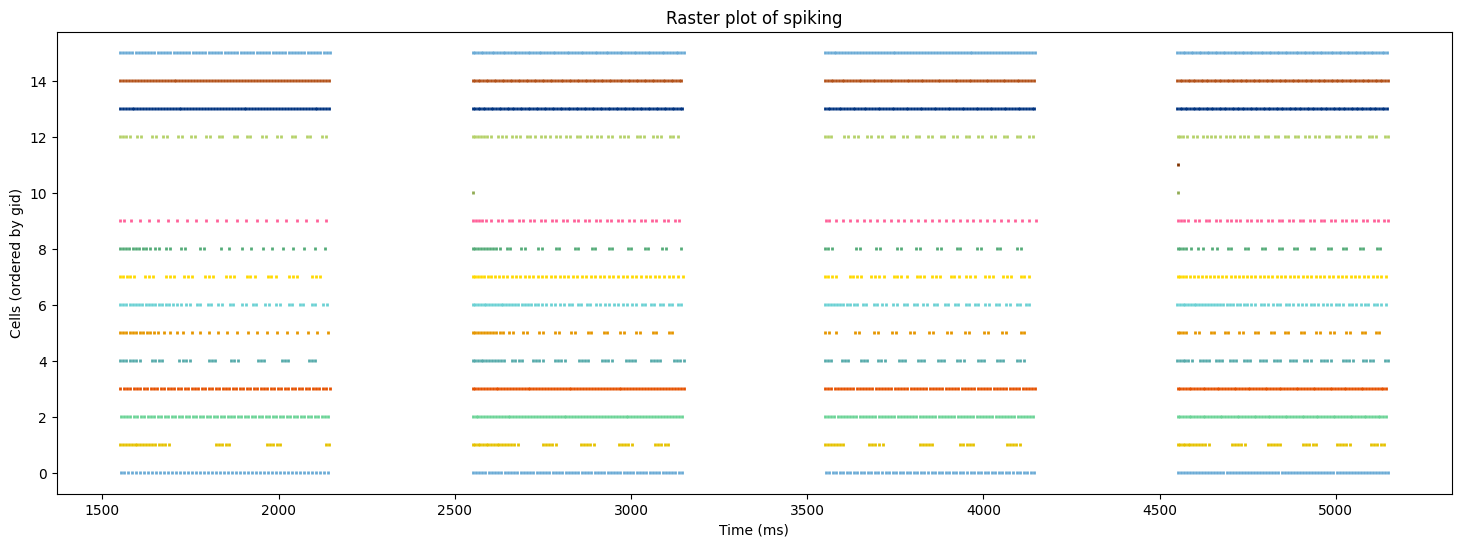

In [15]:
sim.analysis.plotRaster(timeRange=[0,7500], figSize=(18,6), popRates=False, labels = None);

Plotting recorded cell traces ... trace


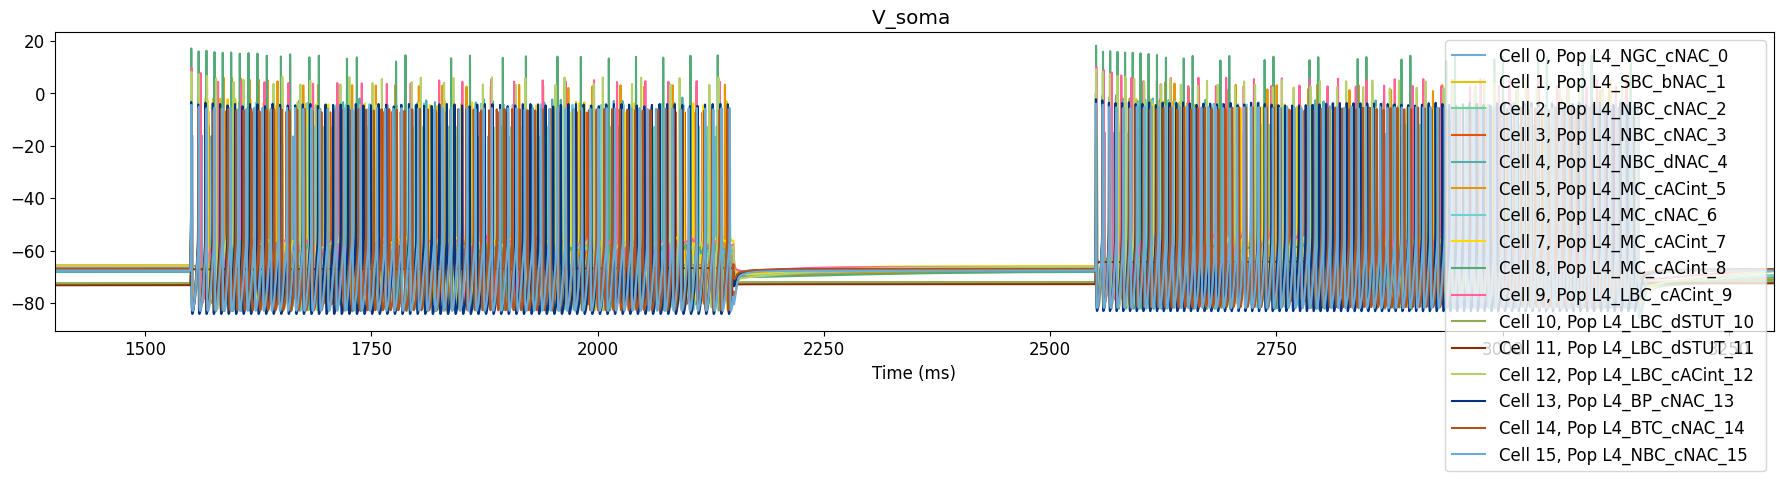

In [205]:
sim.analysis.plotTraces(include= [ii for ii in range(0,16)], timeRange=[1400,3300], axis=True, overlay=True, oneFigPer='trace', figSize=(18,4.5)); #, ylim=[-80, -74]

# Load recordings

In [17]:
# pip install openpyxl

In [174]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

excel_file_path = "Spike_trains_steps_L4_elife_Aric.xlsx"

df_rs = pd.read_excel(excel_file_path, sheet_name="RS")
df_fs = pd.read_excel(excel_file_path, sheet_name="FS")
df_rip = pd.read_excel(excel_file_path, sheet_name="Ripplets")

print("DataFrame for sheet 'RS':")
print(df_rs.head())
print("\nDataFrame for sheet 'FS':")
print(df_fs.head())
print("\nDataFrame for sheet 'Ripplets':")
print(df_rip.head())

DataFrame for sheet 'RS':
     ms    -100      60      70     100     200
0  0.00 -71.045 -70.778 -69.588 -71.480 -70.015
1  0.05 -71.060 -70.686 -69.626 -71.648 -70.061
2  0.10 -71.037 -70.587 -69.618 -71.510 -70.007
3  0.15 -71.091 -70.686 -69.649 -71.503 -69.984
4  0.20 -71.053 -70.625 -69.687 -71.617 -70.061

DataFrame for sheet 'FS':
     ms    -320     240     280     400     600
0  0.00 -68.466 -68.558 -68.886 -69.473 -69.489
1  0.05 -68.390 -68.687 -68.848 -69.450 -69.427
2  0.10 -68.336 -68.703 -68.802 -69.550 -69.359
3  0.15 -68.466 -68.695 -68.871 -69.389 -69.328
4  0.20 -68.474 -68.550 -68.932 -69.679 -69.427

DataFrame for sheet 'Ripplets':
   031820_DFI_P41  FS 5 ms stim  Field  102920_DFI_P36  RS 2 ms stim  Field.1
0            0.00       -66.475 -0.004            0.00       -65.420   -0.046
1            0.05       -66.322 -0.011            0.05       -65.404    0.010
2            0.10       -66.269  0.011            0.10       -65.414    0.074
3            0.15       -6

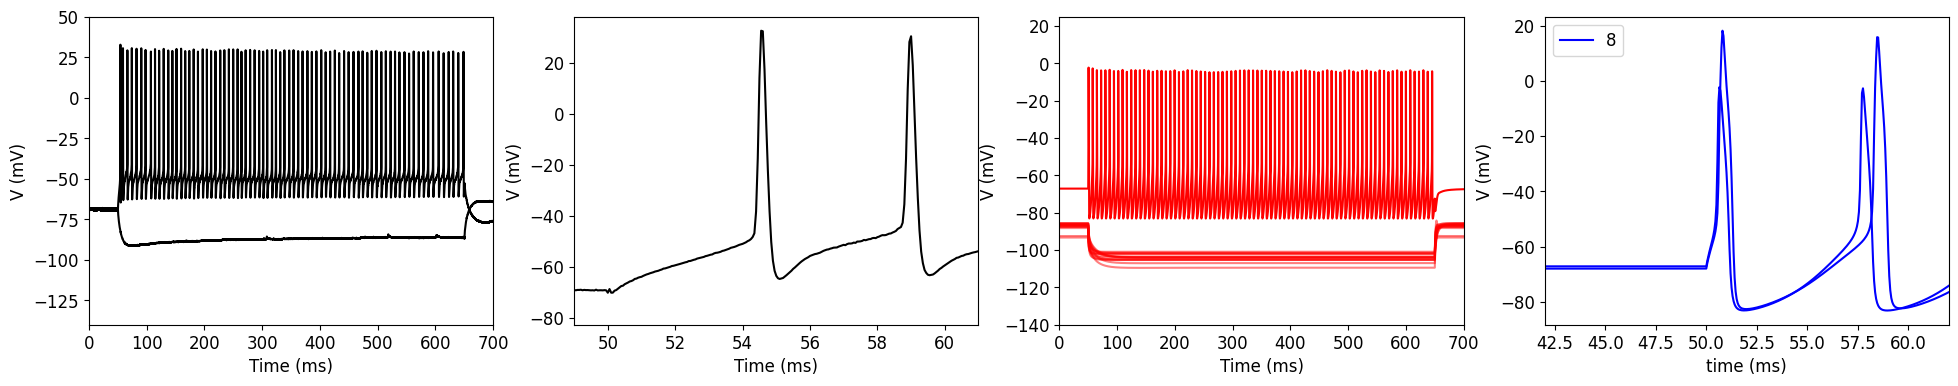

In [175]:
plt.figure(figsize=(24, 4))
i = len(node_gid)
plt.subplot(1, 4, 1)
plt.plot(df_fs['ms'], df_fs[-320]-0, color='k')
plt.plot(df_fs['ms'], df_fs[400], color='k')
plt.ylabel('V (mV)')
plt.xlabel('Time (ms)')
plt.ylim(-140, 50)
plt.xlim(0, 700)

plt.subplot(1, 4, 2)
plt.plot(df_fs['ms'], df_fs[400], color='k')
plt.ylabel('V (mV)')
plt.xlabel('Time (ms)')
plt.xlim(49.0, 61.0)

plt.subplot(1, 4, 3)
for i in range(1, len(node_gid)+1):
    # if np.min(np.array(sim.simData['V_soma']['cell_'+str(i-1)])[0*20000+10000:0*20000+10000+len(df_rs['ms'])]) > -100.0:
        plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(i-1)])[0*20000+10000:0*20000+10000+len(df_rs['ms'])] - 20, color='red',alpha = 0.50)

# plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(i-3)])[0*20000+10000:0*20000+10000+len(df_rs['ms'])] - 20, color='green',alpha = 1.0)
plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(i-3)])[2*20000+10000:2*20000+10000+len(df_rs['ms'])], color='red',alpha = 1.0)
plt.ylabel('V (mV)')
plt.xlabel('Time (ms)')
plt.xlim(0, 700)
plt.ylim(-140, 25)

plt.subplot(1, 4, 4)
for i in range(1, len(node_gid)+1):
    if np.max(np.array(sim.simData['V_soma']['cell_'+str(i-1)])[2*20000+10000:2*20000+10000+len(df_rs['ms'])]) > 15.0:
        plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(i-1)])[2*20000+10000:2*20000+10000+len(df_rs['ms'])], color='blue',alpha = 1.0, label=str(i-1))
plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(i-3)])[2*20000+10000:2*20000+10000+len(df_rs['ms'])], color='blue',alpha = 1.0)
plt.ylabel('V (mV)')
plt.xlim(42.0, 62.0)
plt.ylabel('V (mV)')
plt.legend()
plt.xlabel('time (ms)');

## Compare Resistence (R_Mohm > 300)

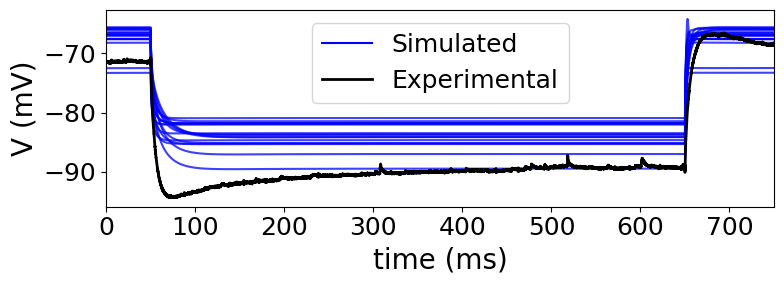

In [176]:
plt.figure(figsize=(8, 3))
plt.ylabel('V (mV)')
plt.xlim(0, 750)
ii = 0
cell_i_good = []
for i in range(1, len(node_gid)+1):
    # if np.min(np.array(sim.simData['V_soma']['cell_'+str(i-1)])[10000:10000+len(df_fs['ms'])]-sim.simData['V_soma']['cell_'+str(i-1)][10000]) > -50:    
        cell_i_good.append(i)
        ii = ii + 1
        plt.plot(df_fs['ms'], np.array(sim.simData['V_soma']['cell_'+str(i-1)])[10000:10000+len(df_fs['ms'])], color='blue', alpha=0.75)
        # plt.plot(df_fs['ms'], df_fs[-320].values, color='cyan')
        plt.ylabel('V (mV)')
        plt.xlim(0, 750)
        # plt.ylim(-115, -58)

    #     mean_swhh.append(np.min(half_widths))
    #     # print("Half-widths (ms):", np.round(half_widths, 3))
    #     print(f"Min SWHH = {np.min(half_widths):.3f} ms  |  ")
    #     print(f"Mean SWHH = {np.nanmean(half_widths):.3f} ms  |  ")
    # else:
plt.plot(df_fs['ms'], np.array(sim.simData['V_soma']['cell_'+str(i-1)])[10000:10000+len(df_fs['ms'])], color='blue', alpha=1.0, label='Simulated')
plt.plot(df_fs['ms'], df_fs[-320].values-3, linewidth = 2.0, color='black', label='Experimental')
plt.ylabel('V (mV)', fontsize=20)
plt.xlabel('time (ms)', fontsize=20)
plt.xlim(0, 750)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(False)
plt.legend(fontsize=18)
plt.tight_layout()
# plt.savefig('Fig4D_L4_FS_step_current-100pA.png', dpi=300)

# plt.show()

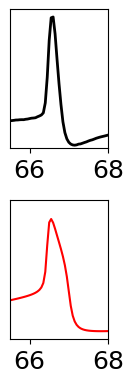

In [229]:
plt.figure(figsize=(1.5, 4.0))
i = len(node_gid)

plt.subplot(2, 1, 1)
plt.plot(df_fs['ms'], df_fs[400].values, linewidth = 2.0, color='black', label='Experimental')
plt.xlim(65.5, 68)
plt.ylim(-65, 35)
plt.xticks(fontsize=18)
plt.yticks([],fontsize=18)
plt.tight_layout()

plt.subplot(2, 1, 2)
plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(i-3)])[1*20000+10000:1*20000+10000+len(df_rs['ms'])], color='red',alpha = 1.0, label='Model')
# plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(4)])[3*20000+10000:3*20000+10000+len(df_rs['ms'])], color='blue',alpha = 1.0, label='Model')
plt.xlim(65.5, 68)
plt.ylim(-90, 10)
plt.yticks([],fontsize=18)
plt.xticks(fontsize=18)
plt.tight_layout()

plt.savefig('Fig_traces_L4_FS_step_400pA_zoom.png', dpi=300)
# plt.show()

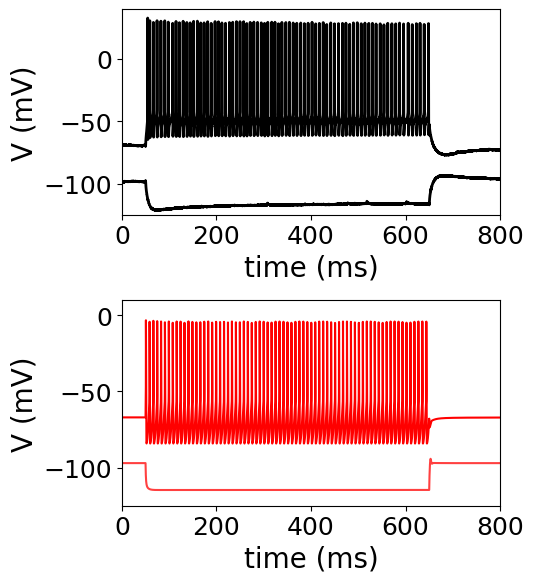

In [178]:
plt.figure(figsize=(5.5, 6.0))
i = len(node_gid)

plt.subplot(2, 1, 1)
plt.plot(df_fs['ms'], df_fs[400].values, linewidth = 2.0, color='black', label='Experimental')
plt.plot(df_fs['ms'], df_fs[-320].values - 30, linewidth = 2.0, color='black')
plt.ylabel('V (mV)', fontsize=20)
plt.xlabel('time (ms)', fontsize=20)
plt.xlim(0, 800)
plt.xticks(fontsize=18)
plt.yticks([-100,-50,0],fontsize=18)
plt.ylim(-125, 40)
plt.tight_layout()

plt.subplot(2, 1, 2)
# for i in range(1, len(node_gid)+1):
#     if sim.simData['V_soma']['cell_'+str(i-1)][10000] > -70:  
#         plt.plot(df_fs['ms'], np.array(sim.simData['V_soma']['cell_'+str(i-1)])[10000:10000+len(df_fs['ms'])], color='red', alpha=0.75)

plt.plot(df_fs['ms'], np.array(sim.simData['V_soma']['cell_'+str(i-3)])[10000:10000+len(df_fs['ms'])] - 30, color='red', alpha=0.75)
plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(i-3)])[1*20000+10000:1*20000+10000+len(df_rs['ms'])], color='red',alpha = 1.0, label='Model')
plt.ylabel('V (mV)', fontsize=20)
plt.xlabel('time (ms)', fontsize=20)
plt.xlim(0, 800)
plt.xticks(fontsize=18)
plt.yticks([-100,-50,0],fontsize=18)
plt.grid(False)
# plt.legend(fontsize=18)
plt.ylim(-125, 10)
plt.tight_layout()

plt.savefig('Fig_traces_L4_FS_step_400pA.png', dpi=300)
# plt.show()

In [179]:
trace_400 = df_fs[400].values
peaks_400, properties_400 = find_peaks(trace_400, prominence=20)
trace_600 = df_fs[600].values
peaks_600, properties_600 = find_peaks(trace_600, prominence=20)

Firing = sim.analysis.calculateRate(timeRange=[1550,2150])
Firing2 = sim.analysis.calculateRate(timeRange=[2550,3150])
freq400 = []
freq600 = []
cell_names = []
FR_RS_400pA = 77/0.600
FR_RS_600pA = 138/0.600
print('%s \t= \t%.2f Hz \t %.2f Hz' % ("RS exp 400 and 600 pA", FR_RS_400pA, FR_RS_600pA))
for i, pop in enumerate(Firing[0]):
    if abs(FR_RS_400pA - Firing[1][i]) < 500.5 and i in cell_i_good:
        print('%s \t= \t%.2f Hz \t %.2f Hz' % (pop, Firing[1][i], Firing2[1][i]))
        freq400.append(Firing[1][i])
        freq600.append(Firing2[1][i])
        cell_names.append(pop)
        
# Firing[1]
cells_110hz = []
for i, pop in enumerate(Firing[0]):
    if Firing[1][i] > 10.0 and i in cell_i_good:
        cells_110hz.append(pop)

print("Cells with firing frequency > 50 Hz:", cells_110hz)

Calculating avg and peak firing rates ...
Calculating avg and peak firing rates ...
RS exp 400 and 600 pA 	= 	128.33 Hz 	 230.00 Hz
L4_NGC_cNAC_0 	= 	88.33 Hz 	 110.00 Hz
L4_SBC_bNAC_1 	= 	48.33 Hz 	 61.67 Hz
L4_NBC_cNAC_2 	= 	101.67 Hz 	 120.00 Hz
L4_NBC_cNAC_3 	= 	103.33 Hz 	 121.67 Hz
L4_NBC_dNAC_4 	= 	50.00 Hz 	 73.33 Hz
L4_MC_cACint_5 	= 	51.67 Hz 	 55.00 Hz
L4_MC_cNAC_6 	= 	75.00 Hz 	 91.67 Hz
L4_MC_cACint_7 	= 	53.33 Hz 	 83.33 Hz
L4_MC_cACint_8 	= 	48.33 Hz 	 51.67 Hz
L4_LBC_cACint_9 	= 	38.33 Hz 	 66.67 Hz
L4_LBC_dSTUT_10 	= 	0.00 Hz 	 1.67 Hz
L4_LBC_dSTUT_11 	= 	0.00 Hz 	 0.00 Hz
L4_LBC_cACint_12 	= 	53.33 Hz 	 71.67 Hz
L4_BP_cNAC_13 	= 	120.00 Hz 	 133.33 Hz
L4_BTC_cNAC_14 	= 	118.33 Hz 	 131.67 Hz
L4_NBC_cNAC_15 	= 	111.67 Hz 	 126.67 Hz
Cells with firing frequency > 50 Hz: ['L4_NGC_cNAC_0', 'L4_SBC_bNAC_1', 'L4_NBC_cNAC_2', 'L4_NBC_cNAC_3', 'L4_NBC_dNAC_4', 'L4_MC_cACint_5', 'L4_MC_cNAC_6', 'L4_MC_cACint_7', 'L4_MC_cACint_8', 'L4_LBC_cACint_9', 'L4_LBC_cACint_12', 'L4_BP_c

In [180]:
# Análise de resistência de membrana
# Rin = ΔV / I

# ------------------------------------------------------------------------------ #
# Cálculo da resistência de entrada (Rin) a partir dos dados experimentais
# ------------------------------------------------------------------------------ #

I = -320

mask_step = (df_fs['ms'] >= 150) & (df_fs['ms'] <= 500)

mask_rest = (df_fs['ms'] >= 0) & (df_fs['ms'] <= 50)

V_step_exp = df_fs[-320][mask_step].mean()
V_rest_exp = df_fs[-320][mask_rest].mean()
delta_V_exp = V_step_exp - V_rest_exp 
Rin_exp = delta_V_exp / I  

print(f"FS patch: \t ΔV = {delta_V_exp:.2f} mV, Rm = {1000*Rin_exp:.2f} MΩ")

# ------------------------------------------------------------------------------ #
# Cálculo da resistência Simulada
# ------------------------------------------------------------------------------ #


time = np.arange(0, sim.cfg.duration + sim.cfg.dt, sim.cfg.dt)


index_450ms = np.argmin(np.abs(time - 450))
index_1000ms = np.argmin(np.abs(time - 1000))

cell_voltages = {}
for cell_full_name in cell_names:
    try:
        gid = cell_full_name.split('_')[-1]
        cell_name_key = f"cell_{gid}" 

        if cell_name_key in sim.simData['V_soma']:
            soma_voltage_trace = sim.simData['V_soma'][cell_name_key]
            
            if index_1000ms < len(soma_voltage_trace):
                voltage_450ms = soma_voltage_trace[index_450ms]
                voltage_1000ms = soma_voltage_trace[index_1000ms]
                
                cell_voltages[cell_full_name] = { #
                    'V_450ms': voltage_450ms,
                    'V_1000ms': voltage_1000ms
                }
                # print(f"{cell_full_name}: V_soma aos 450 ms = {voltage_450ms:.2f} mV, V_soma aos 1000 ms = {voltage_1000ms:.2f} mV")
            else:
                print(f"Aviso: O trace de voltagem para {cell_full_name} ({cell_name_key}) é muito curto para acessar 1000 ms.")
        else:
            print(f"Aviso: Dados de V_soma não encontrados para a chave: {cell_name_key} (original: {cell_full_name})")
    except Exception as e:
        print(f"Erro ao processar a célula {cell_full_name}: {e}")
        
I = -320 #pA
membrane_resistances = []

for cell_full_name, voltages in cell_voltages.items():
    delta_V = voltages['V_1000ms'] - voltages['V_450ms']
    
    Rm = (delta_V / I) * 1000
    membrane_resistances.append(Rm)


    print(f"{cell_full_name}: \t ΔV = {delta_V:.2f} mV, Rm = {Rm:.2f} MΩ")

FS patch: 	 ΔV = -18.92 mV, Rm = 59.13 MΩ
L4_NGC_cNAC_0: 	 ΔV = -16.86 mV, Rm = 52.70 MΩ
L4_SBC_bNAC_1: 	 ΔV = -18.82 mV, Rm = 58.80 MΩ
L4_NBC_cNAC_2: 	 ΔV = -13.28 mV, Rm = 41.49 MΩ
L4_NBC_cNAC_3: 	 ΔV = -18.63 mV, Rm = 58.21 MΩ
L4_NBC_dNAC_4: 	 ΔV = -16.97 mV, Rm = 53.03 MΩ
L4_MC_cACint_5: 	 ΔV = -18.12 mV, Rm = 56.63 MΩ
L4_MC_cNAC_6: 	 ΔV = -14.65 mV, Rm = 45.77 MΩ
L4_MC_cACint_7: 	 ΔV = -21.26 mV, Rm = 66.44 MΩ
L4_MC_cACint_8: 	 ΔV = -18.25 mV, Rm = 57.02 MΩ
L4_LBC_cACint_9: 	 ΔV = -18.02 mV, Rm = 56.32 MΩ
L4_LBC_dSTUT_10: 	 ΔV = -9.42 mV, Rm = 29.43 MΩ
L4_LBC_dSTUT_11: 	 ΔV = -8.67 mV, Rm = 27.09 MΩ
L4_LBC_cACint_12: 	 ΔV = -23.55 mV, Rm = 73.61 MΩ
L4_BP_cNAC_13: 	 ΔV = -17.60 mV, Rm = 54.99 MΩ
L4_BTC_cNAC_14: 	 ΔV = -16.49 mV, Rm = 51.54 MΩ
L4_NBC_cNAC_15: 	 ΔV = -14.20 mV, Rm = 44.38 MΩ


## Comparing FR (400 pA and 600 pA)

experimental FS cells
Mean SWHH = 0.347 ms  |  
Cell L4_NGC_cNAC_0
Mean SWHH = 0.803 ms  |  
Cell L4_SBC_bNAC_1
Mean SWHH = 0.656 ms  |  
Cell L4_NBC_cNAC_2
Mean SWHH = 0.681 ms  |  
Cell L4_NBC_cNAC_3
Mean SWHH = 0.709 ms  |  
Cell L4_NBC_dNAC_4
Mean SWHH = 0.561 ms  |  
Cell L4_MC_cACint_5
Mean SWHH = 0.679 ms  |  
Cell L4_MC_cNAC_6
Mean SWHH = 0.593 ms  |  
Cell L4_MC_cACint_7
Mean SWHH = 0.716 ms  |  
Cell L4_MC_cACint_8
Mean SWHH = 0.656 ms  |  
Cell L4_LBC_cACint_9
Mean SWHH = 0.700 ms  |  
Cell L4_LBC_dSTUT_10
Mean SWHH = 0.567 ms  |  
Cell L4_LBC_dSTUT_11
Mean SWHH = nan ms  |  
Cell L4_LBC_cACint_12
Mean SWHH = 0.701 ms  |  
Cell L4_BP_cNAC_13
Mean SWHH = 0.621 ms  |  
Cell L4_BTC_cNAC_14
Mean SWHH = 0.650 ms  |  
Cell L4_NBC_cNAC_15
Mean SWHH = 0.626 ms  |  
Cell L4_NGC_cNAC_0
Min SWHH = 0.693 ms  |  
Cell L4_SBC_bNAC_1
Min SWHH = 0.526 ms  |  
Cell L4_NBC_cNAC_2
Min SWHH = 0.578 ms  |  
Cell L4_NBC_cNAC_3
Min SWHH = 0.614 ms  |  
Cell L4_NBC_dNAC_4
Min SWHH = 0.432 ms  |  
C

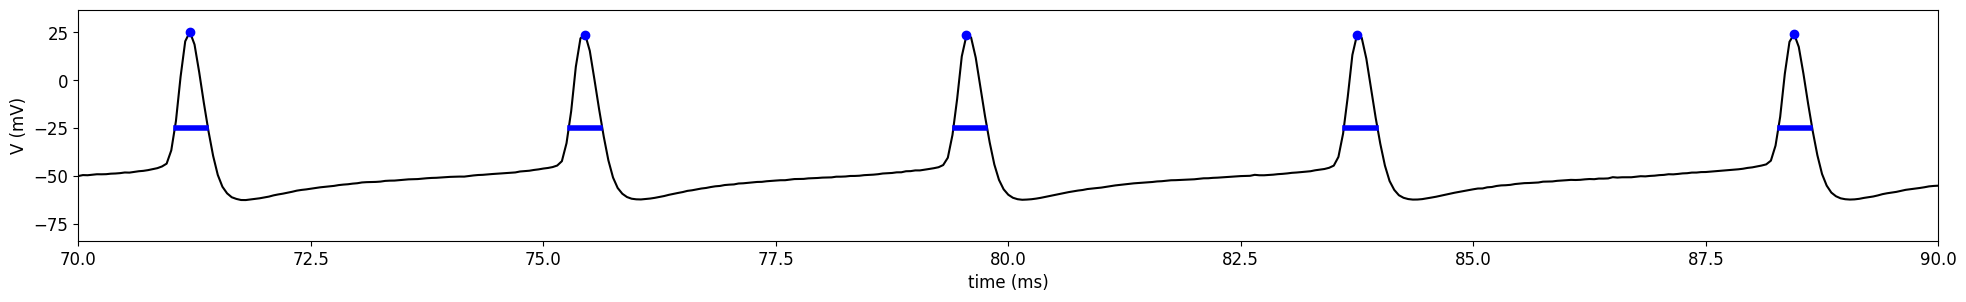

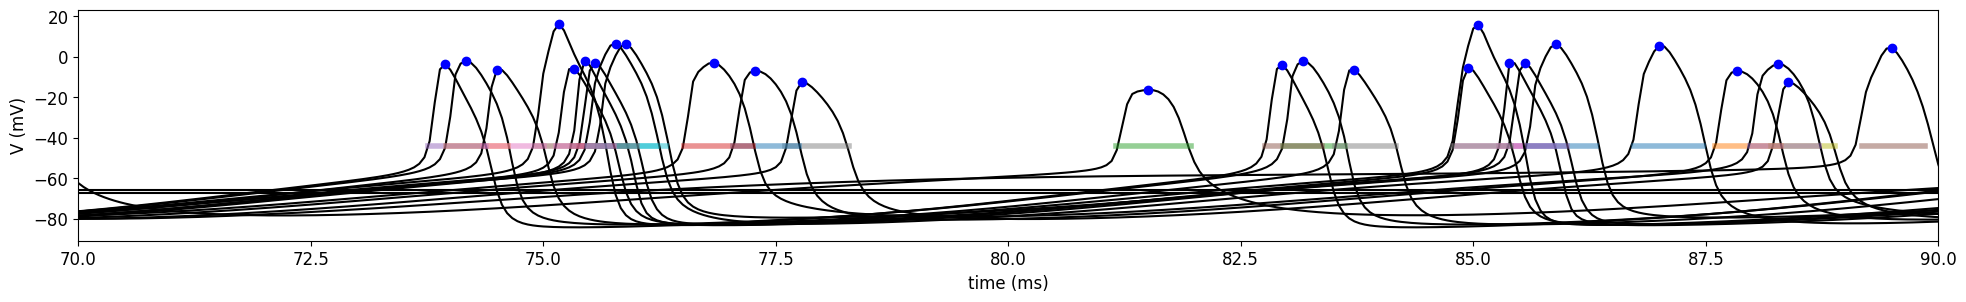

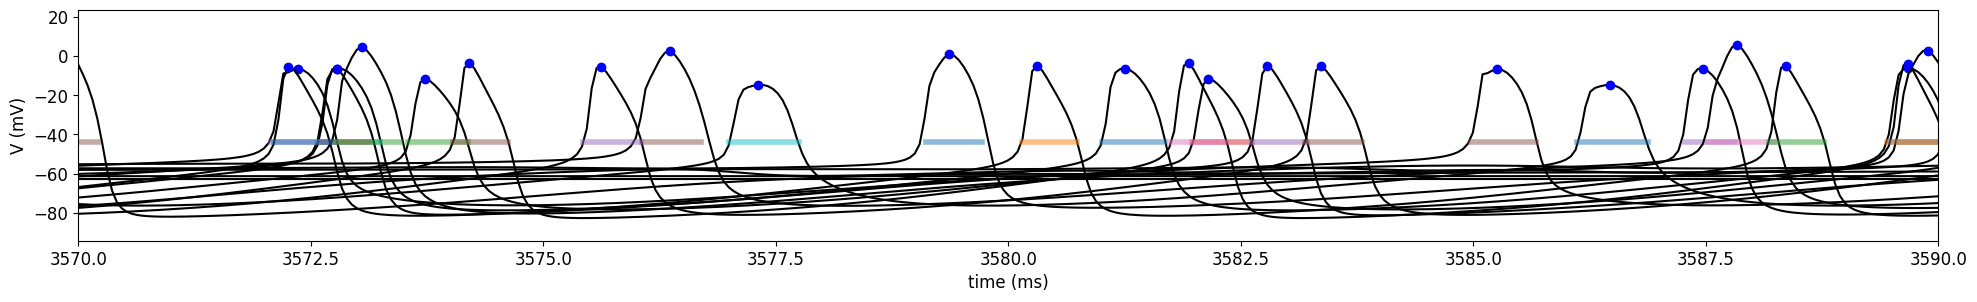

In [ ]:
def measure_swhh(trace, time, baseline_ms=20, rise_ms=3):
    dt = time[1] - time[0]
    baseline_window = int(baseline_ms / dt)
    rise_window = int(rise_ms / dt)

    peaks, _ = find_peaks(trace, prominence=20)
    widths = []   
    ti = []
    tf = []

    for peak_idx in peaks:
        peak_v = trace[peak_idx]
        baseline_idx = max(0, peak_idx - baseline_window)
        baseline_v = np.min(trace[baseline_idx:peak_idx])
        half = baseline_v + 0.5 * (peak_v - baseline_v)

        start_i = max(baseline_idx, peak_idx - rise_window)
        t_left = None
        for i in range(start_i, peak_idx):
            if trace[i] <= half and trace[i+1] > half:
                t_left = time[i] + (half - trace[i]) * (time[i+1]-time[i]) / (trace[i+1]-trace[i])
                # break
        
        t_right = None
        for i in range(peak_idx, len(trace)-1):
            if trace[i] >= half and trace[i+1] < half:
                t_right = time[i] + (half - trace[i]) * (time[i+1]-time[i]) / (trace[i+1]-trace[i])
                break

        if t_left is not None and t_right is not None:
            widths.append(t_right - t_left)
            ti.append(t_left)
            tf.append(t_right)

    return peaks, widths, ti, tf

# ------------------------------------------------------------------------------ #
# experimental FS
# ------------------------------------------------------------------------------ #
print("experimental FS cells")

time = np.array(df_fs['ms'])       # ms
trace = np.array(df_fs[600])       # voltage trace (mV)

peaks, half_widths, ti, tf = measure_swhh(trace, time,
                                       baseline_ms=10,
                                       rise_ms=3)

if len(half_widths):
    # print("Half-widths (ms):", np.round(half_widths, 3))
    print(f"Mean SWHH = {np.nanmean(half_widths):.3f} ms  |  ")

plt.figure(figsize=(24, 3))
plt.ylabel('V (mV)')
plt.plot(time, trace, color='black')
plt.plot(time[peaks], trace[peaks], "o", color='blue')
plt.plot([ti, tf], [-25, -25], "-", color='blue', linewidth=4.0)
plt.ylabel('V (mV)')
plt.xlabel('time (ms)')
plt.xlim(70, 90)

# ------------------------------------------------------------------------------ #
# experimental FS
# ------------------------------------------------------------------------------ #
# Calculate mean SWHH for each cell in freq100

mean_swhh = []

plt.figure(figsize=(24, 3))
for i, cell in enumerate(cell_names):

    print("Cell" , cell)
    time = np.linspace(0,2000, len(np.array(sim.simData['V_soma']['cell_'+str(i)])[1*20000+10000:2*20000+10000+len(df_rs['ms'])]))          # ms
    trace = np.array(sim.simData['V_soma']['cell_'+str(i)])[1*20000+10000:2*20000+10000+len(df_rs['ms'])]       # voltage trace (mV)

    peaks, half_widths, ti, tf = measure_swhh(trace, time,
                                        baseline_ms=10,
                                        rise_ms=3)

    plt.ylabel('V (mV)')
    plt.plot(time, trace, color='black')
    plt.plot(time[peaks], trace[peaks], "o", color='blue')
    plt.plot([ti, tf], [-44, -44], "-",  linewidth=4.0, alpha=0.5)
    plt.ylabel('V (mV)')
    plt.xlabel('time (ms)')
    plt.xlim(70, 90)

    if len(half_widths):
        mean_swhh.append(np.min(half_widths))
        # print("Half-widths (ms):", np.round(half_widths, 3))
        # print(f"Min SWHH = {np.min(half_widths):.3f} ms  |  ")
        print(f"Mean SWHH = {np.nanmean(half_widths):.3f} ms  |  ")
    else:
        mean_swhh.append(np.nanmean(half_widths))
        # print("Half-widths (ms):", np.round(half_widths, 3))
        print(f"Mean SWHH = {np.nanmean(half_widths):.3f} ms  |  ")


# ------------------------------------------------------------------------------ #
# model FS
# ------------------------------------------------------------------------------ #
# Calculate min SWHH for each cell in freq100

mim_swhh = []

plt.figure(figsize=(24, 3))
for i, cell in enumerate(cell_names):

    print("Cell" , cell)
    time = np.linspace(0,4000, len(np.array(sim.simData['V_soma']['cell_'+str(i)])[1*20000+10000:4*20000+10000+len(df_rs['ms'])]))          # ms
    trace = np.array(sim.simData['V_soma']['cell_'+str(i)])[1*20000+10000:4*20000+10000+len(df_rs['ms'])]       # voltage trace (mV)

    peaks, half_widths, ti, tf = measure_swhh(trace, time,
                                        baseline_ms=10,
                                        rise_ms=3)

    plt.ylabel('V (mV)')
    plt.plot(time, trace, color='black')
    plt.plot(time[peaks], trace[peaks], "o", color='blue')
    plt.plot([ti, tf], [-44, -44], "-",  linewidth=4.0, alpha=0.5)
    plt.ylabel('V (mV)')
    plt.xlabel('time (ms)')
    plt.xlim(3570, 3590)

    if len(half_widths):
        mim_swhh.append(np.min(half_widths))
        # print("Half-widths (ms):", np.round(half_widths, 3))
        print(f"Min SWHH = {np.min(half_widths):.3f} ms  |  ")
        # print(f"Mean SWHH = {np.nanmean(half_widths):.3f} ms  |  ")
    else:
        mim_swhh.append(np.nanmean(half_widths))
        # print("Half-widths (ms):", np.round(half_widths, 3))
        print(f"Min SWHH = {np.nanmean(half_widths):.3f} ms  |  ")

In [182]:
with open("summary_metrics_RS_simuled.json", "r") as f:
    summary_metrics = json.load(f)

print(summary_metrics.keys())

dict_keys(['mean_swhh', 'membrane_resistances', 'freq100', 'freq200'])


In [183]:
mean_swhhRS = summary_metrics['mean_swhh']
membrane_resistancesRS = summary_metrics['membrane_resistances']
freq100RS = summary_metrics['freq100']
freq200RS = summary_metrics['freq200']

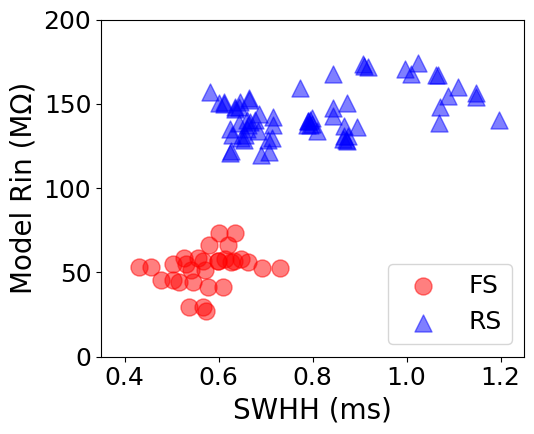

In [184]:
plt.figure(figsize=(5.5, 4.5))
plt.scatter(mean_swhh, membrane_resistances, marker='o', s=150, alpha=0.5, color='red', edgecolors='r', label='FS')
plt.scatter(mim_swhh, membrane_resistances, marker='o', s=150, alpha=0.5, color='red', edgecolors='r')
plt.scatter(mean_swhhRS, membrane_resistancesRS, marker='^', s=150, alpha=0.5, color='blue', edgecolors='b', label='RS')
plt.xlabel('SWHH (ms)', fontsize=20)
plt.xlim(0.35, 1.25)
plt.ylabel('Model Rin (MΩ)', fontsize=20)
# plt.title('Membrane Resistance vs. Mean SWHH', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks([0, 50, 100, 150, 200], fontsize=18)
plt.grid(False)
plt.legend(fontsize=18)
plt.tight_layout()
plt.savefig('Fig_SWHH_L4_RS_FS_step_100pA.png', dpi=300)


In [185]:
Firing3 = sim.analysis.calculateRate(timeRange=[3550,4150])
Firing4 = sim.analysis.calculateRate(timeRange=[4550,5150])
freq800 = []
freq1000 = []
cell_names = []
print('%s \t= \t%.2f Hz \t %.2f Hz' % ("RS exp 400 and 600 pA", FR_RS_400pA, FR_RS_600pA))
for i, pop in enumerate(Firing[0]):
        print('%s \t\t= \t\t%.2f Hz \t %.2f Hz \t%.2f Hz \t %.2f Hz' % (pop, Firing[1][i], Firing2[1][i], Firing3[1][i], Firing4[1][i]))
        freq800.append(Firing3[1][i])
        freq1000.append(Firing4[1][i])

Calculating avg and peak firing rates ...
Calculating avg and peak firing rates ...
RS exp 400 and 600 pA 	= 	128.33 Hz 	 230.00 Hz
allCells 		= 		66.35 Hz 	 81.25 Hz 	69.69 Hz 	 83.33 Hz
L4_NGC_cNAC_0 		= 		88.33 Hz 	 110.00 Hz 	100.00 Hz 	 116.67 Hz
L4_SBC_bNAC_1 		= 		48.33 Hz 	 61.67 Hz 	45.00 Hz 	 61.67 Hz
L4_NBC_cNAC_2 		= 		101.67 Hz 	 120.00 Hz 	111.67 Hz 	 125.00 Hz
L4_NBC_cNAC_3 		= 		103.33 Hz 	 121.67 Hz 	111.67 Hz 	 125.00 Hz
L4_NBC_dNAC_4 		= 		50.00 Hz 	 73.33 Hz 	55.00 Hz 	 75.00 Hz
L4_MC_cACint_5 		= 		51.67 Hz 	 55.00 Hz 	38.33 Hz 	 50.00 Hz
L4_MC_cNAC_6 		= 		75.00 Hz 	 91.67 Hz 	75.00 Hz 	 95.00 Hz
L4_MC_cACint_7 		= 		53.33 Hz 	 83.33 Hz 	61.67 Hz 	 85.00 Hz
L4_MC_cACint_8 		= 		48.33 Hz 	 51.67 Hz 	35.00 Hz 	 48.33 Hz
L4_LBC_cACint_9 		= 		38.33 Hz 	 66.67 Hz 	51.67 Hz 	 70.00 Hz
L4_LBC_dSTUT_10 		= 		0.00 Hz 	 1.67 Hz 	0.00 Hz 	 1.67 Hz
L4_LBC_dSTUT_11 		= 		0.00 Hz 	 0.00 Hz 	0.00 Hz 	 1.67 Hz
L4_LBC_cACint_12 		= 		53.33 Hz 	 71.67 Hz 	58.33 Hz 	 73.33 Hz
L4_BP

In [186]:
freq400 = np.array(freq400)
freq600 = np.array(freq600)
freq800 = np.array(freq800)
freq1000 = np.array(freq1000)

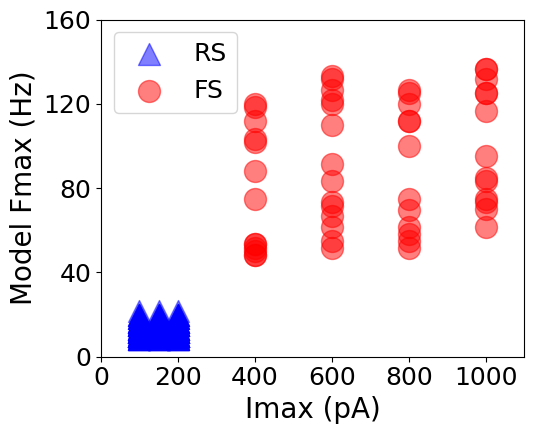

In [187]:
plt.figure(figsize=(5.5, 4.5))
plt.scatter(100.0*np.ones(len(freq100RS)), freq100RS, marker='^', s=250, alpha=0.5, color='blue', edgecolors='b', label='RS')
plt.scatter(150.0*np.ones(len(freq200RS)), freq100RS, marker='^', s=250, alpha=0.5, color='blue', edgecolors='b')
plt.scatter(200.0*np.ones(len(freq200RS)), freq100RS, marker='^', s=250, alpha=0.5, color='blue', edgecolors='b')
plt.scatter(400.0*np.ones(len(freq400[freq400>40])), freq400[freq400>40], marker='o', s=250, alpha=0.5, color='red', edgecolors='r', label='FS')
plt.scatter(600.0*np.ones(len(freq600[freq600>50])), freq600[freq600>50], marker='o', s=250, alpha=0.5, color='red', edgecolors='r')
plt.scatter(800.0*np.ones(len(freq800[freq800>50])), freq800[freq800>50], marker='o', s=250, alpha=0.5, color='red', edgecolors='r')
plt.scatter(1000.0*np.ones(len(freq1000[freq1000>50])), freq1000[freq1000>50], marker='o', s=250, alpha=0.5, color='red', edgecolors='r')
plt.xlabel('Imax (pA)', fontsize=20)
plt.xlim(0, 1100.0)
plt.ylabel('Model Fmax (Hz)', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks([0, 40 ,80, 120, 160], fontsize=18)
plt.grid(False)
plt.legend(fontsize=18)
plt.tight_layout()
plt.savefig('Fig_FR_L4_RS_FS_step_100-600pA.png', dpi=300)


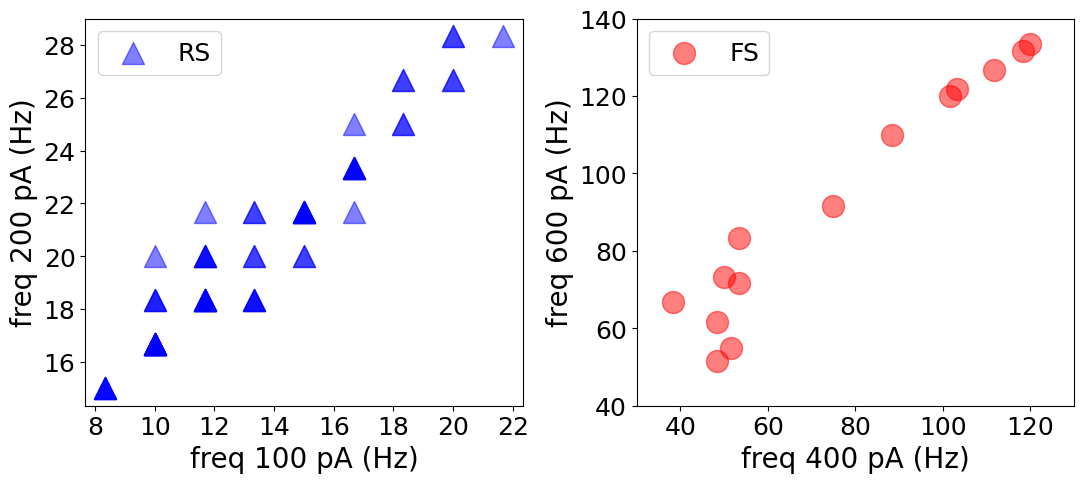

In [188]:
plt.figure(figsize=(11, 5))
plt.subplot(1, 2, 1)
plt.scatter(freq100RS, freq200RS, marker='^', s=250, alpha=0.5, color='blue', edgecolors='b', label='RS')
plt.xlabel('freq 100 pA (Hz)', fontsize=20)
# plt.xlim(0, 1.5)
plt.ylabel('freq 200 pA (Hz)', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(False)
plt.legend(fontsize=18)
plt.tight_layout()

plt.subplot(1, 2, 2)
plt.scatter(freq400, freq600, marker='o', s=250, alpha=0.5, color='red', edgecolors='r', label='FS')
plt.xlabel('freq 400 pA (Hz)', fontsize=20)
plt.xlim(30, 130)
plt.ylim(40, 140)
plt.ylabel('freq 600 pA (Hz)', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(False)
plt.legend(fontsize=18)
plt.tight_layout()


# plt.savefig('Fig_FR_L4_RS_step_100_200pA.png', dpi=300)


In [189]:
# data_to_save = {
#     "mean_swhh": list(mean_swhh),
#     "membrane_resistances": list(membrane_resistances),
#     "freq400": list(freq400),
#     "freq600": list(freq200)
# }

# with open("summary_metrics_FS_simuled.json", "w") as f:
#     json.dump(data_to_save, f, indent=2)

### Ultra Fast Ripples

(0.0, 25.0)

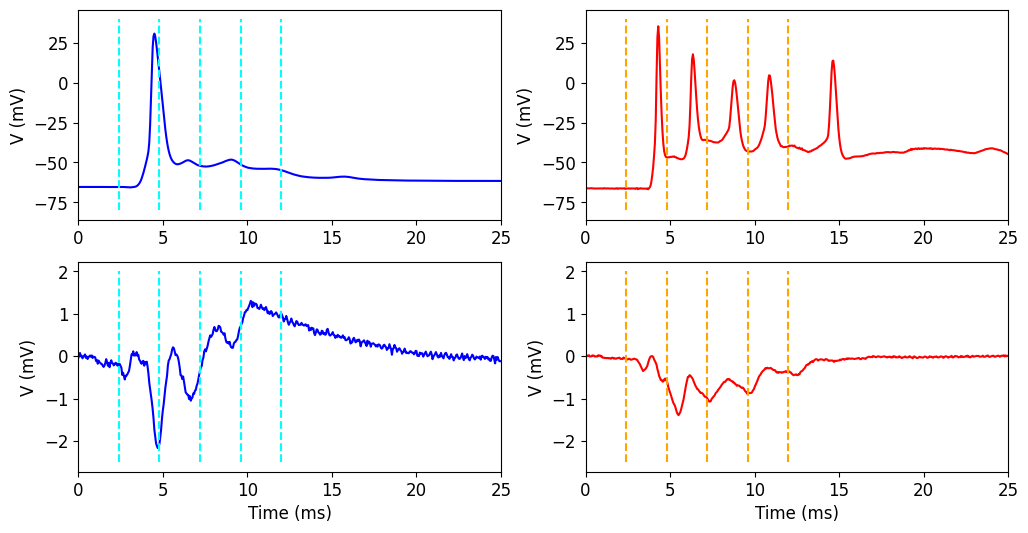

In [190]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.plot(df_rip['102920_DFI_P36'], df_rip['RS 2 ms stim'], color='blue')
plt.vlines(x=[2.4,4.8,7.2,9.6,12.0],ymin=-80, ymax=40, colors='cyan', linestyles='dashed')
plt.ylabel('V (mV)')
plt.xlim(0, 25)
plt.subplot(2, 2, 3)
plt.plot(df_rip['102920_DFI_P36'], df_rip['Field.1'], color='blue')
plt.vlines(x=[2.4,4.8,7.2,9.6,12.0],ymin=-2.5, ymax=2, colors='cyan', linestyles='dashed')
plt.ylabel('V (mV)')
plt.xlabel('Time (ms)')
plt.xlim(0, 25)

plt.subplot(2, 2, 2)
plt.plot(df_rip['031820_DFI_P41'], df_rip['FS 5 ms stim'], color='red')
plt.vlines(x=[2.4,4.8,7.2,9.6,12.0],ymin=-80, ymax=40, colors='orange', linestyles='dashed')
plt.ylabel('V (mV)')
plt.xlim(0, 25)
plt.subplot(2, 2, 4)
plt.plot(df_rip['031820_DFI_P41'], df_rip['Field'], color='red')
plt.vlines(x=[2.4,4.8,7.2,9.6,12.0],ymin=-2.5, ymax=2, colors='orange', linestyles='dashed')
plt.ylabel('V (mV)')
plt.xlabel('Time (ms)')
plt.xlim(0, 25)